# Lecture 14 Demo: Course Recap and QML Decision Tool

**Lecturer:** Pavel Sulimov

**ZHAW Quantum Machine Learning Course**

**Convention:** All qubits start in state |0> unless otherwise specified.

This is an interactive visualization recap covering all 14 lectures. We create:
1. A course taxonomy chart
2. A decision tree for when to use quantum vs classical
3. A comparison table of all QML approaches

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

---

## Demo 1: Course Taxonomy Visualization

The 14 lectures span six QML categories:

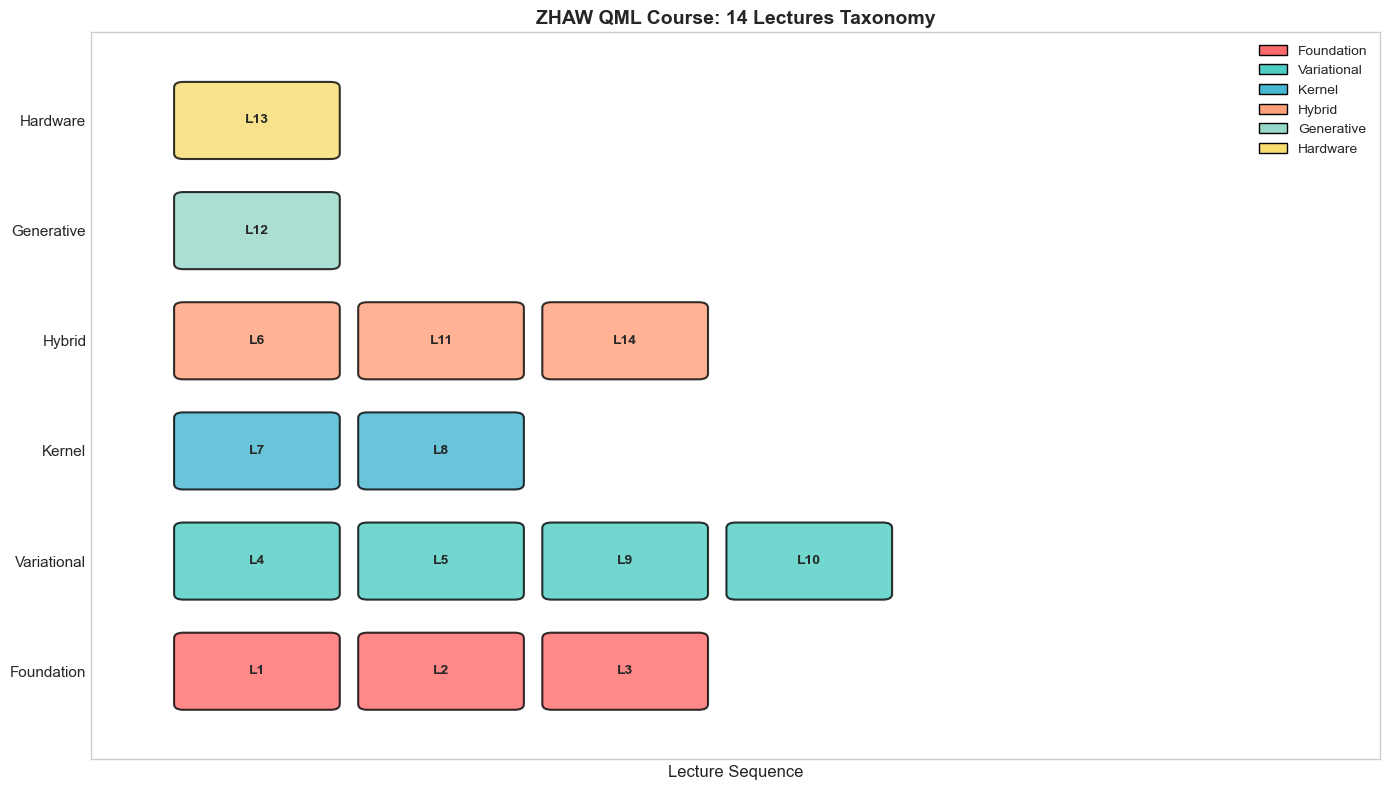

Course Structure:
  Foundation: Lectures 1, 2, 3
  Variational: Lectures 4, 5, 9, 10
  Kernel: Lectures 7, 8
  Hybrid: Lectures 6, 11, 14
  Generative: Lectures 12
  Hardware: Lectures 13


In [2]:
lectures = [
    {'num': 1, 'title': 'Quantum Basics', 'category': 'Foundation'},
    {'num': 2, 'title': 'Gates & Circuits', 'category': 'Foundation'},
    {'num': 3, 'title': 'Measurements & Observables', 'category': 'Foundation'},
    {'num': 4, 'title': 'Parameterized Circuits', 'category': 'Variational'},
    {'num': 5, 'title': 'Variational Quantum Classifier', 'category': 'Variational'},
    {'num': 6, 'title': 'QAOA', 'category': 'Hybrid'},
    {'num': 7, 'title': 'Quantum Kernel Methods', 'category': 'Kernel'},
    {'num': 8, 'title': 'QSVM', 'category': 'Kernel'},
    {'num': 9, 'title': 'Quantum CNNs', 'category': 'Variational'},
    {'num': 10, 'title': 'Structured QML', 'category': 'Variational'},
    {'num': 11, 'title': 'Quantum Reservoir Computing', 'category': 'Hybrid'},
    {'num': 12, 'title': 'Generative Models', 'category': 'Generative'},
    {'num': 13, 'title': 'Noise & Error Mitigation', 'category': 'Hardware'},
    {'num': 14, 'title': 'Course Recap', 'category': 'Hybrid'},
]

categories = ['Foundation', 'Variational', 'Kernel', 'Hybrid', 'Generative', 'Hardware']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']
cat_to_color = {cat: color for cat, color in zip(categories, colors)}

fig, ax = plt.subplots(figsize=(14, 8))

y_positions = {cat: i for i, cat in enumerate(categories)}
x_offsets = {cat: 0 for cat in categories}

for lec in lectures:
    cat = lec['category']
    y = y_positions[cat]
    x = x_offsets[cat]
    
    rect = FancyBboxPatch((x, y - 0.3), 0.8, 0.6, 
                          boxstyle="round,pad=0.05", 
                          edgecolor='black', 
                          facecolor=cat_to_color[cat],
                          linewidth=1.5, alpha=0.8)
    ax.add_patch(rect)
    
    ax.text(x + 0.4, y, f"L{lec['num']}", 
           ha='center', va='center', fontsize=10, fontweight='bold')
    
    x_offsets[cat] += 1.0

ax.set_xlim(-0.5, 6.5)
ax.set_ylim(-0.8, 5.8)
ax.set_yticks(range(len(categories)))
ax.set_yticklabels(categories, fontsize=11)
ax.set_xticks([])
ax.set_xlabel('Lecture Sequence', fontsize=12)
ax.set_title('ZHAW QML Course: 14 Lectures Taxonomy', fontsize=14, fontweight='bold')
ax.grid(False)

legend_elements = [mpatches.Patch(facecolor=cat_to_color[cat], edgecolor='black', label=cat) 
                   for cat in categories]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print("Course Structure:")
for cat in categories:
    lecs = [str(l['num']) for l in lectures if l['category'] == cat]
    print(f"  {cat}: Lectures {', '.join(lecs)}")

---

## Demo 2: Decision Tree for Quantum vs Classical

When should you use Quantum Machine Learning?

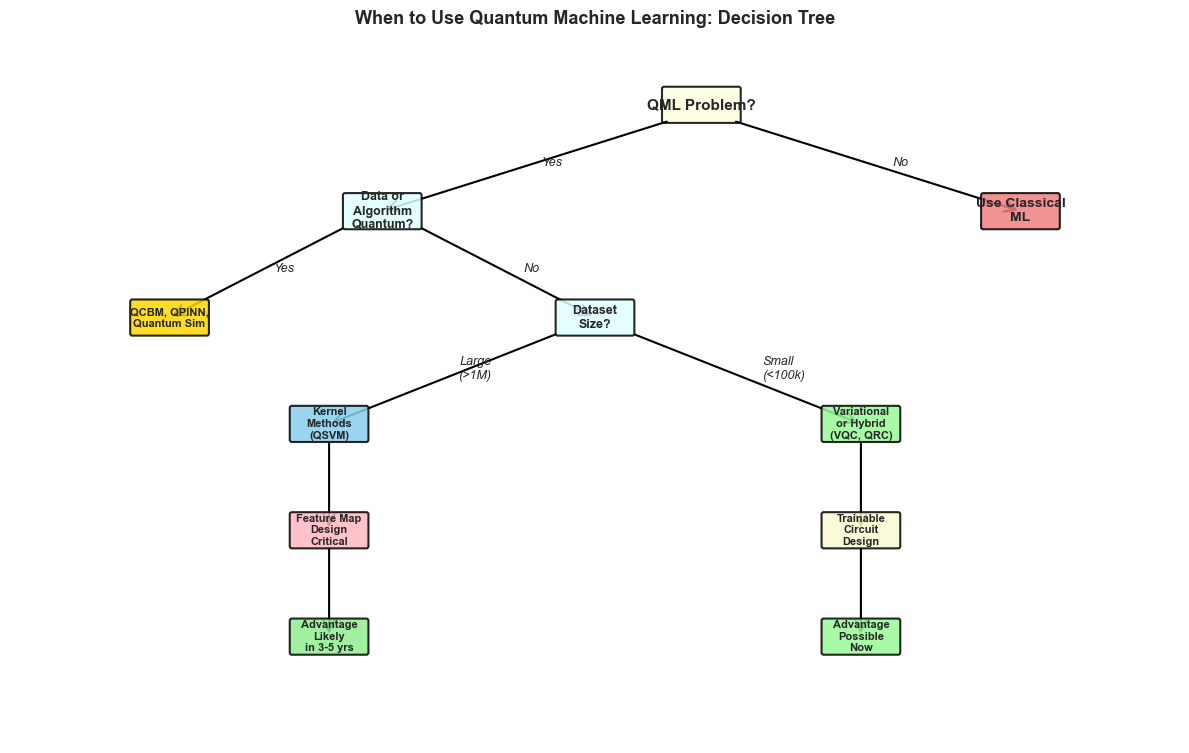

In [3]:
fig, ax = plt.subplots(figsize=(12, 10))

def draw_node(ax, x, y, text, color='lightblue', fontsize=10):
    rect = FancyBboxPatch((x - 0.35, y - 0.15), 0.7, 0.3,
                          boxstyle="round,pad=0.02",
                          edgecolor='black',
                          facecolor=color,
                          linewidth=1.5, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', 
           fontsize=fontsize, fontweight='bold', wrap=True)

def draw_arrow(ax, x1, y1, x2, y2, label=''):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', mutation_scale=20,
                           linewidth=1.5, color='black')
    ax.add_patch(arrow)
    if label:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mid_x + 0.15, mid_y, label, fontsize=9, style='italic')

draw_node(ax, 6, 9, 'QML Problem?', 'lightyellow', 11)

draw_arrow(ax, 5.7, 8.85, 3, 8, 'Yes')
draw_arrow(ax, 6.3, 8.85, 9, 8, 'No')

draw_node(ax, 3, 8, 'Data or\nAlgorithm\nQuantum?', 'lightcyan', 9)
draw_node(ax, 9, 8, 'Use Classical\nML', 'lightcoral', 10)

draw_arrow(ax, 2.65, 7.85, 1, 7, 'Yes')
draw_arrow(ax, 3.35, 7.85, 5, 7, 'No')

draw_node(ax, 1, 7, 'QCBM, QPINN,\nQuantum Sim', '#FFD700', 8)
draw_node(ax, 5, 7, 'Dataset\nSize?', 'lightcyan', 9)

draw_arrow(ax, 4.65, 6.85, 2.5, 6, 'Large\n(>1M)')
draw_arrow(ax, 5.35, 6.85, 7.5, 6, 'Small\n(<100k)')

draw_node(ax, 2.5, 6, 'Kernel\nMethods\n(QSVM)', '#87CEEB', 8)
draw_node(ax, 7.5, 6, 'Variational\nor Hybrid\n(VQC, QRC)', '#98FB98', 8)

draw_arrow(ax, 2.5, 5.85, 2.5, 5, '')
draw_arrow(ax, 7.5, 5.85, 7.5, 5, '')

draw_node(ax, 2.5, 5, 'Feature Map\nDesign\nCritical', '#FFB6C1', 8)
draw_node(ax, 7.5, 5, 'Trainable\nCircuit\nDesign', '#FAFAD2', 8)

draw_arrow(ax, 2.5, 4.85, 2.5, 4, '')
draw_arrow(ax, 7.5, 4.85, 7.5, 4, '')

draw_node(ax, 2.5, 4, 'Advantage\nLikely\nin 3-5 yrs', '#90EE90', 8)
draw_node(ax, 7.5, 4, 'Advantage\nPossible\nNow', '#98FB98', 8)

ax.set_xlim(-0.5, 10.5)
ax.set_ylim(3, 9.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('When to Use Quantum Machine Learning: Decision Tree', 
            fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

---

## Demo 3: QML Approaches Comparison Table

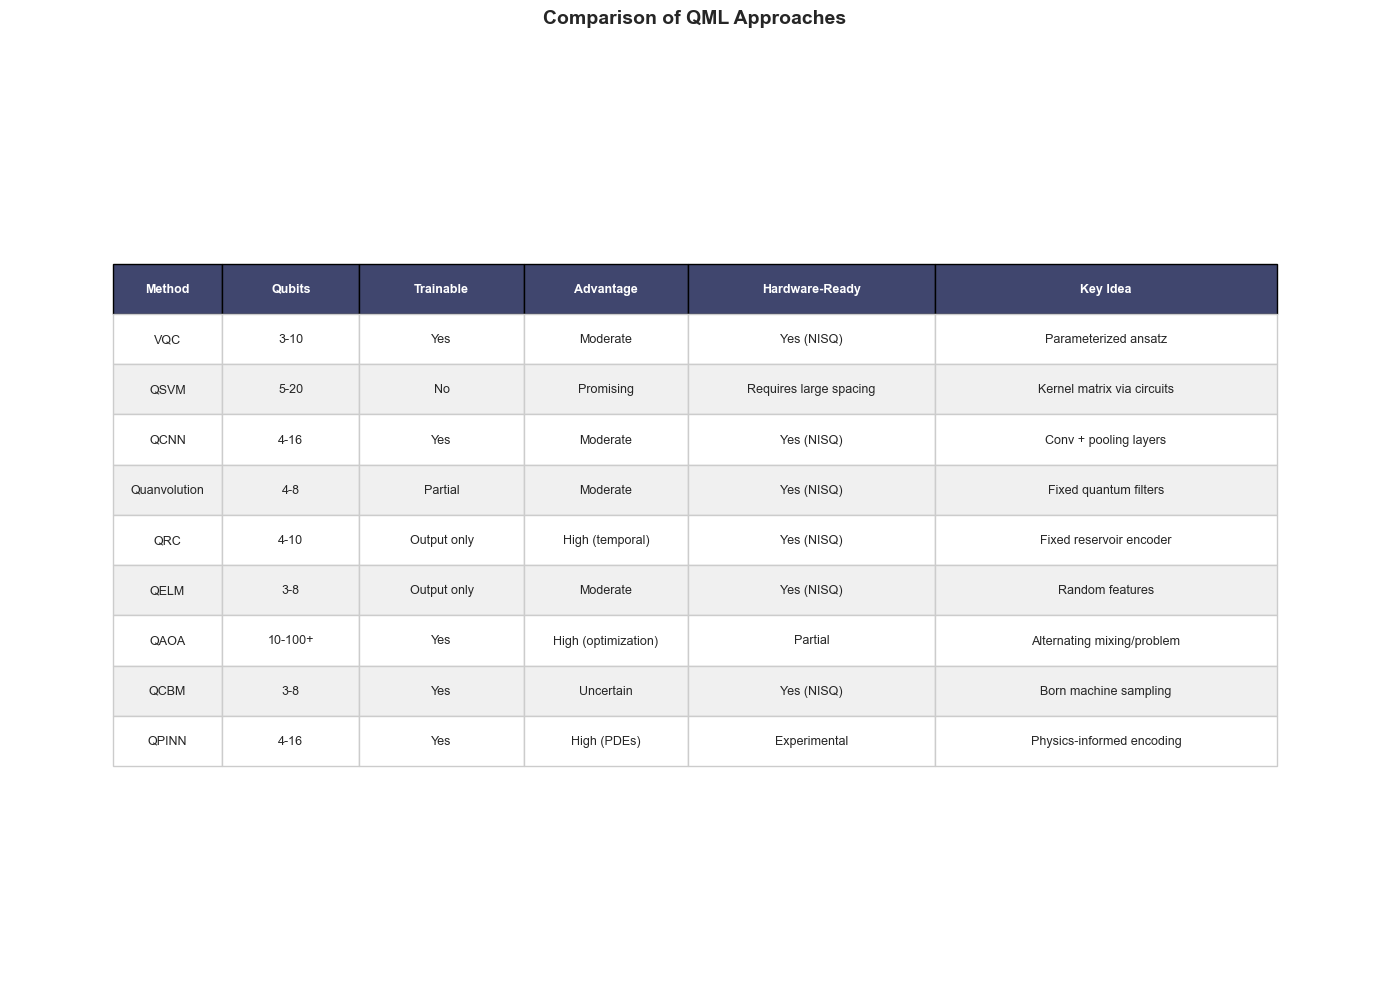

QML Methods Summary:
  VQC: Parameterized ansatz
  QSVM: Kernel matrix via circuits
  QCNN: Conv + pooling layers
  Quanvolution: Fixed quantum filters
  QRC: Fixed reservoir encoder
  QELM: Random features
  QAOA: Alternating mixing/problem
  QCBM: Born machine sampling
  QPINN: Physics-informed encoding


In [4]:
qml_methods = {
    'VQC': {
        'qubit_count': '3-10',
        'trainable': 'Yes',
        'advantage': 'Moderate',
        'hardware_ready': 'Yes (NISQ)',
        'key_idea': 'Parameterized ansatz'
    },
    'QSVM': {
        'qubit_count': '5-20',
        'trainable': 'No',
        'advantage': 'Promising',
        'hardware_ready': 'Requires large spacing',
        'key_idea': 'Kernel matrix via circuits'
    },
    'QCNN': {
        'qubit_count': '4-16',
        'trainable': 'Yes',
        'advantage': 'Moderate',
        'hardware_ready': 'Yes (NISQ)',
        'key_idea': 'Conv + pooling layers'
    },
    'Quanvolution': {
        'qubit_count': '4-8',
        'trainable': 'Partial',
        'advantage': 'Moderate',
        'hardware_ready': 'Yes (NISQ)',
        'key_idea': 'Fixed quantum filters'
    },
    'QRC': {
        'qubit_count': '4-10',
        'trainable': 'Output only',
        'advantage': 'High (temporal)',
        'hardware_ready': 'Yes (NISQ)',
        'key_idea': 'Fixed reservoir encoder'
    },
    'QELM': {
        'qubit_count': '3-8',
        'trainable': 'Output only',
        'advantage': 'Moderate',
        'hardware_ready': 'Yes (NISQ)',
        'key_idea': 'Random features'
    },
    'QAOA': {
        'qubit_count': '10-100+',
        'trainable': 'Yes',
        'advantage': 'High (optimization)',
        'hardware_ready': 'Partial',
        'key_idea': 'Alternating mixing/problem'
    },
    'QCBM': {
        'qubit_count': '3-8',
        'trainable': 'Yes',
        'advantage': 'Uncertain',
        'hardware_ready': 'Yes (NISQ)',
        'key_idea': 'Born machine sampling'
    },
    'QPINN': {
        'qubit_count': '4-16',
        'trainable': 'Yes',
        'advantage': 'High (PDEs)',
        'hardware_ready': 'Experimental',
        'key_idea': 'Physics-informed encoding'
    },
}

fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('tight')
ax.axis('off')

columns = ['Method', 'Qubits', 'Trainable', 'Advantage', 'Hardware-Ready', 'Key Idea']
rows = []

for method, props in qml_methods.items():
    row = [
        method,
        props['qubit_count'],
        props['trainable'],
        props['advantage'],
        props['hardware_ready'],
        props['key_idea']
    ]
    rows.append(row)

table = ax.table(cellText=rows, colLabels=columns, cellLoc='center', loc='center',
                colWidths=[0.08, 0.10, 0.12, 0.12, 0.18, 0.25])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.5)

for i in range(len(columns)):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, len(rows) + 1):
    for j in range(len(columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('#ffffff')
        table[(i, j)].set_edgecolor('#cccccc')

ax.set_title('Comparison of QML Approaches', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("QML Methods Summary:")
for method in qml_methods:
    print(f"  {method}: {qml_methods[method]['key_idea']}")

---

## Summary

The ZHAW QML course covers:

1. **Foundation (Lectures 1-3):** Quantum mechanics basics, gates, circuits, measurements.

2. **Variational Algorithms (Lectures 4, 5, 9, 10):** Parameterized circuits, VQE, VQC, QCNN, structured QML.

3. **Kernel Methods (Lectures 7, 8):** Quantum feature maps, quantum kernels, QSVM.

4. **Hybrid Approaches (Lectures 6, 11, 14):** QAOA, quantum reservoir computing, integration with classical ML.

5. **Generative Models (Lecture 12):** QCBM, QPINN, generative quantum circuits.

6. **Hardware Considerations (Lecture 13):** Noise, error mitigation, realistic device constraints.

**Key Takeaways:**
- Quantum advantage is problem-specific and data-dependent.
- Near-term devices (NISQ) suit hybrid and variational approaches.
- Error mitigation is essential for current hardware.
- Classical baselines must always be compared.